# Complete carbon-dioxide coverage in the ThermoML snapshot

**Question.** Which experimental records in the versioned NIST/TRC ThermoML
snapshot involve carbon dioxide as a component, including pure CO₂ and every
multicomponent system containing CO₂?

**Success criteria.** Identify CO₂ by its standard InChIKey; verify the
snapshot checksum; include every semantically matching dataset; report the
same top-10 rankings used in the general archive analysis; and rank datasets
only after the complete snapshot has been scanned.

In [1]:
from __future__ import annotations

import platform
from dataclasses import asdict
from importlib.metadata import version
from pathlib import Path
from time import perf_counter

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

from thermoml_io import (
    analyze_thermoml_archive,
    fetch_thermoml_archive,
    get_archive_source,
)

pd.set_option("display.max_colwidth", 120)


def find_project_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").is_file():
            return candidate
    raise RuntimeError("Could not locate the thermoml-io project root.")


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
print(
    {
        "python": platform.python_version(),
        "thermoml-io": version("thermoml-io"),
        "pandas": version("pandas"),
        "platform": platform.platform(),
    }
)

{'python': '3.14.6', 'thermoml-io': '0.1.0', 'pandas': '3.0.5', 'platform': 'macOS-26.5.2-arm64-arm-64bit-Mach-O'}


## Chemical identity and source

Formula/name searches can be ambiguous. The analysis uses the standard
InChIKey for carbon dioxide and then confirms component membership through
parsed ThermoML references. A serialized-key check is used only as a fast
prefilter.

In [2]:
COMPONENT_LABEL = "carbon dioxide"
COMPONENT_FORMULA = "CO2"
COMPONENT_INCHIKEY = "CURLTUGMZLYLDI-UHFFFAOYSA-N"
archive_source = get_archive_source()
ARCHIVE_PATH = fetch_thermoml_archive(
    cache_dir=PROJECT_ROOT / "notebooks/local-only/archive"
)
display(
    pd.DataFrame(
        [
            {
                "component": COMPONENT_LABEL,
                "formula": COMPONENT_FORMULA,
                "standard InChIKey": COMPONENT_INCHIKEY,
                "snapshot DOI": archive_source.doi.removeprefix("doi:"),
                "cutoff": "entries published through 2019",
                "SHA-256": archive_source.sha256,
            }
        ]
    )
)

,component,formula,standard InChIKey,snapshot DOI,cutoff,SHA-256
0,carbon dioxide,CO2,CURLTUGMZLYLDI-UHFFFAOYSA-N,10.18434/mds2-2422,entries published through 2019,231161b5e443dc1ae0e5da8429d86a88474cb722016e5b790817bb31c58d7ec2


## All datasets containing CO₂

`component=` means inclusion: binary, ternary, quaternary, and higher-order
systems remain eligible. It does not require CO₂ to be the measured property
target, only a referenced component of the experimental system.

In [3]:
started = perf_counter()
analysis = analyze_thermoml_archive(
    ARCHIVE_PATH,
    component=COMPONENT_INCHIKEY,
    serialized_prefilter=COMPONENT_INCHIKEY,
    top_datasets=10,
    on_error="collect",
)
elapsed_seconds = perf_counter() - started
summary = analysis.summary

overview = pd.DataFrame(
    {
        "metric": [
            "XML members in snapshot",
            "XML members passing InChIKey prefilter",
            "publications with matching datasets",
            "datasets containing CO2",
            "NumValues data points",
            "property observations",
            "official JSON recoveries after prefilter",
            "unrecovered failures after prefilter",
            "elapsed seconds",
        ],
        "count": [
            analysis.xml_document_count,
            analysis.parsed_document_count,
            analysis.matched_document_count,
            summary.dataset_count,
            summary.data_point_count,
            summary.observation_count,
            len(analysis.recoveries),
            len(analysis.failures),
            round(elapsed_seconds, 2),
        ],
    }
)
display(overview)

,metric,count
0,XML members in snapshot,11923.0
1,XML members passing InChIKey prefilter,1421.0
2,publications with matching datasets,1078.0
3,datasets containing CO2,3789.0
4,NumValues data points,126252.0
5,property observations,129176.0
6,official JSON recoveries after prefilter,0.0
7,unrecovered failures after prefilter,0.0
8,elapsed seconds,10.8


## Top-10 rankings for CO₂-containing systems

Counts are observation-weighted except for the explicitly labelled dataset
system-order ranking.

In [4]:
RANKINGS = (
    ("data_types", "Derived data categories"),
    ("property_groups", "Original ThermoML property groups"),
    ("properties", "Reported properties"),
    ("dataset_system_types", "System orders — datasets"),
    ("system_types", "System orders — observations"),
    ("systems", "Chemical systems containing CO2"),
    ("components", "Components in CO2-containing systems"),
    ("methods", "Experimental methods"),
    ("publications", "Publications"),
)

ranking_frames: dict[str, pd.DataFrame] = {}
for field, title in RANKINGS:
    frame = pd.DataFrame(
        [
            {"rank": rank, "label": item.label, "count": item.count}
            for rank, item in enumerate(summary.top(field, 10), start=1)
        ]
    )
    ranking_frames[field] = frame
    print(f"\n{title} — top 10")
    display(frame)


Derived data categories — top 10


,rank,label,count
0,1,volumetric,36948
1,2,VLE,32564
2,3,vapor pressure and boiling,29277
3,4,phase equilibrium,10065
4,5,transport,7034
5,6,"interfacial, optical, and acoustic",6169
6,7,excess and partial energy,3227
7,8,critical property,1410
8,9,phase transition,1027
9,10,caloric,558



Original ThermoML property groups — top 10


,rank,label,count
0,1,CompositionAtPhaseEquilibrium,43516
1,2,VolumetricProp,36948
2,3,VaporPBoilingTAzeotropTandP,29277
3,4,TransportProp,7034
4,5,RefractionSurfaceTensionSoundSpeed,6169
5,6,ExcessPartialApparentEnergyProp,3227
6,7,Criticals,1410
7,8,PhaseTransition,1027
8,9,HeatCapacityAndDerivedProp,558
9,10,ActivityFugacityOsmoticProp,10



Reported properties — top 10


...

,rank,label,count
0,1,carbon dioxide,129176
1,2,water,25544
2,3,methanol,6505
3,4,ethanol,5922
4,5,decane,3237
5,6,sodium chloride,3198
6,7,acetone,3127
7,8,2-aminoethan-1-ol,2786
8,9,methane,2062
9,10,nitrogen,1815



Experimental methods — top 10


,rank,label,count
0,1,Vibrating tube method,18057
1,2,Closed cell (Static) method,17242
2,3,Chromatography,11236
3,4,Phase equilibration,5128
4,5,Pycnometric method,4184
5,6,Pendant drop shape,3178
6,7,CCELL:UFactor:8,2307
7,8,Buoyancy - hydrostatic balance with magnetic suspension - one sinker,2286
8,9,CCELL:UFactor:16,1980
9,10,Flow calorimetry,1859



Publications — top 10


,rank,label,count
0,1,10.1016/j.jct.2016.03.026,3939
1,2,10.1021/je900387e,2101
2,3,10.1021/acs.jced.6b00858,1463
3,4,10.1021/je0601457,1350
4,5,10.1021/je034160c,1013
5,6,10.1021/je400056z,999
6,7,10.1016/j.jct.2007.07.005,991
7,8,10.1021/je300530z,937
8,9,10.1016/j.jct.2018.05.015,850
9,10,10.1021/je034087q,823


## CO₂ as component and its most frequent co-components

Every retained observation belongs to a system containing CO₂. The target
component count therefore provides a useful internal accounting check.

In [5]:
component_counts = pd.DataFrame(
    [
        {"component": item.label, "observations": item.count}
        for item in summary.components
    ]
)
target_count = int(
    component_counts.loc[
        component_counts["component"].str.casefold() == COMPONENT_LABEL,
        "observations",
    ].sum()
)
assert target_count == summary.observation_count
co_components = component_counts[
    component_counts["component"].str.casefold() != COMPONENT_LABEL
].head(10)
display(
    pd.DataFrame(
        [
            {
                "accounting check": "CO2 component observations",
                "count": target_count,
                "expected": summary.observation_count,
            }
        ]
    )
)
display(co_components)

,accounting check,count,expected
0,CO2 component observations,129176,129176


,component,observations
1,water,25544
2,methanol,6505
3,ethanol,5922
4,decane,3237
5,sodium chloride,3198
6,acetone,3127
7,2-aminoethan-1-ol,2786
8,methane,2062
9,nitrogen,1815
10,pentane,1410


## Ten densest CO₂-containing datasets

In [6]:
dense_records = []
for rank, item in enumerate(analysis.top_datasets, start=1):
    record = asdict(item)
    locator = record.pop("source_locator")
    record["archive_member"] = locator.rsplit("!", maxsplit=1)[-1] if locator else None
    dense_records.append({"rank": rank, **record})
display(pd.DataFrame(dense_records))

,rank,doi,citation_title,dataset_number,system,system_type,observation_count,data_types,archive_member
0,1,10.1016/j.jct.2016.03.026,Thermodynamic properties of a CO2-rich mixture (CO2 + CH3OH) in conditions of interest for carbon dioxide capture an...,2,carbon dioxide + methanol,binary,3341,"(volumetric,)",10.1016/j.jct.2016.03.026.xml
1,2,10.1021/acs.jced.6b00858,"Measurement of Interfacial Tension of CO2 and NaCl Aqueous Solution over Wide Temperature, Pressure, and Salinity Ra...",2,carbon dioxide + sodium chloride + water,ternary,1188,"(interfacial, optical, and acoustic,)",10.1021/acs.jced.6b00858.xml
2,3,10.1016/j.jct.2007.07.005,Compressed liquid densities and excess molar volumes for (CO2 + 1-pentanol) binary system at temperatures from 313 t...,2,carbon dioxide + pentan-1-ol,binary,991,"(volumetric,)",10.1016/j.jct.2007.07.005.xml
3,4,10.1016/j.jct.2018.05.015,PVTx and thermal-pressure coefficient measurements of the binary CO2 + n-decane mixtures in the critical and retrogr...,1,carbon dioxide + decane,binary,767,"(volumetric,)",10.1016/j.jct.2018.05.015.xml
4,5,10.1021/je900387e,"Phase Behavior, Densities, and Isothermal Compressibility of Carbon Dioxide + 1-Bromobutane, Carbon Dioxide + 1-Chlo...",5,1-bromobutane + carbon dioxide,binary,751,"(volumetric,)",10.1021/je900387e.xml
5,6,10.1016/j.fluid.2005.06.010,Measurements of solid solubilities and volumetric properties of naphthalene + carbon dioxide mixtures with a new ass...,4,carbon dioxide + naphthalene,binary,675,"(volumetric,)",10.1016/j.fluid.2005.06.010.xml
6,7,10.1021/je900387e,"Phase Behavior, Densities, and Isothermal Compressibility of Carbon Dioxide + 1-Bromobutane, Carbon Dioxide + 1-Chlo...",10,1-chlorobutane + carbon dioxide,binary,675,"(volumetric,)",10.1021/je900387e.xml
7,8,10.1021/je700261b,Measurements of Compressed Liquid Densities for CO2 (1) + Butan-1-ol (2) via a Vibrating Tube Densimeter at Temperat...,2,butan-1-ol + carbon dioxide,binary,668,"(volumetric,)",10.1021/je700261b.xml
8,9,10.1021/je050050p,"Compressed Liquid Densities and Excess Volumes for the Binary System CO2 + N,N-Dimethylformamide (DMF) from (313 to ...",2,carbon dioxide + dimethylformamide,binary,667,"(volumetric,)",10.1021/je050050p.xml
9,10,10.1021/je8007759,"Phase Behavior, Densities, and Isothermal Compressibility of CO2 + a-Valerolactone Systems in Various Phase Regions",12,.gamma.-valerolactone + carbon dioxide,binary,648,"(volumetric,)",10.1021/je8007759.xml


## Visual comparison

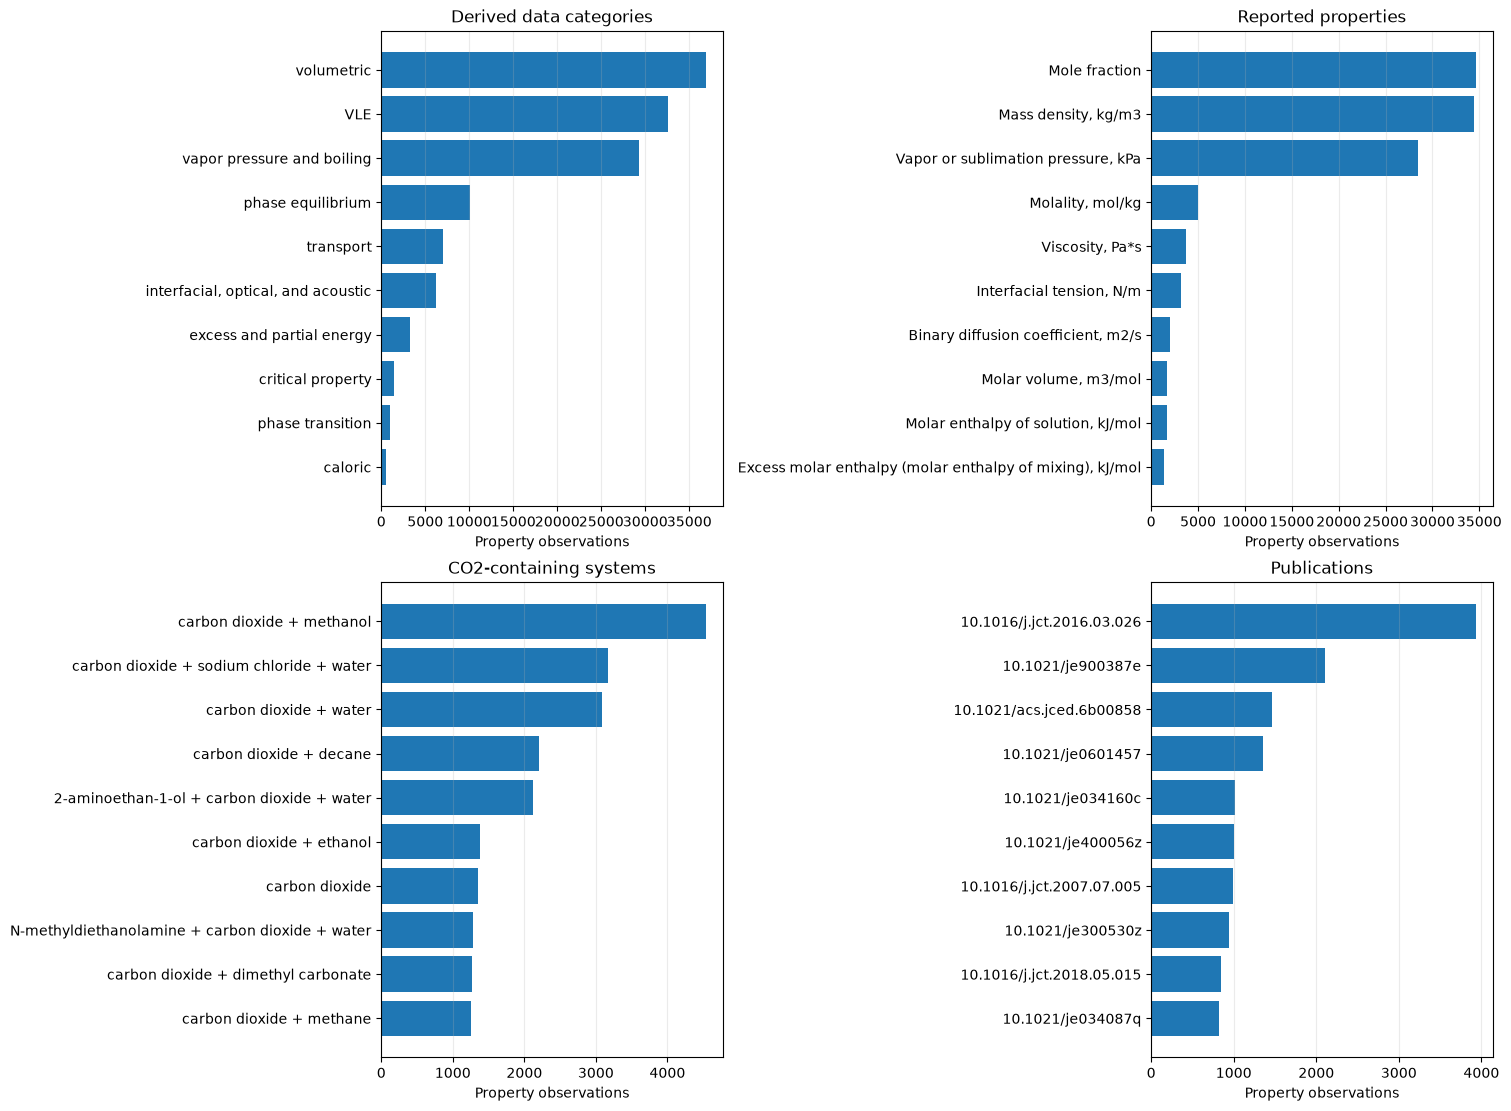

In [7]:
figure, axes = plt.subplots(2, 2, figsize=(15, 11), constrained_layout=True)
for axis, field, title in (
    (axes[0, 0], "data_types", "Derived data categories"),
    (axes[0, 1], "properties", "Reported properties"),
    (axes[1, 0], "systems", "CO2-containing systems"),
    (axes[1, 1], "publications", "Publications"),
):
    frame = ranking_frames[field].sort_values("count")
    axis.barh(frame["label"], frame["count"])
    axis.set_title(title)
    axis.set_xlabel("Property observations")
    axis.grid(axis="x", alpha=0.25)
plt.show()

## Recoveries, failures, and limitations

In [8]:
recovery_frame = pd.DataFrame(
    [
        {
            "XML member": item.xml_member_name,
            "JSON member": item.json_member_name,
            "XML error": item.error_message,
        }
        for item in analysis.recoveries
    ]
)
if recovery_frame.empty:
    print("No CO2-prefiltered XML member required paired-JSON recovery.")
else:
    display(recovery_frame)

No CO2-prefiltered XML member required paired-JSON recovery.


In [9]:
failure_frame = pd.DataFrame(
    [
        {
            "archive_member": item.member_name,
            "error_type": item.error_type,
            "message": item.message,
        }
        for item in analysis.failures
    ]
)
if failure_frame.empty:
    print("No CO2-prefiltered member remained undecodable.")
else:
    display(failure_frame)

No CO2-prefiltered member remained undecodable.


- “All” means every matching supported `PureOrMixtureData` dataset in the
  pinned snapshot, whose publication cutoff is 2019.
- `ReactionData` is not associated with components in the v0.1 typed model
  and is therefore outside this component-specific census.
- Counts measure stored property observations, not independent experiments or
  critically evaluated recommended values.
- NIST/TRC checks representation completeness but does not critically
  evaluate the underlying measurements; consult the original publications
  before calibration or validation work.